In [1]:
#import packages used throught the notebook
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

In [2]:
#get jobs to examine the first few rows of each table
query = """
SELECT TOP 5 *
FROM gaiadr3.gaia_source"""

g_sum_job = Gaia.launch_job(query)

query = """
SELECT TOP 5 *
FROM gaiadr1.tmass_original_valid"""

t_sum_job = Gaia.launch_job(query)


In [3]:
#look at the first few lines of each table
g_sum = g_sum_job.get_results()
print('Gaia dr3')
print(g_sum.colnames)
#print(g_sum['designation','source_id'])
t_sum = t_sum_job.get_results()
print('TMass')
print(t_sum.colnames)
#print(t_sum['designation','ext_key','tmass_oid'])

Gaia dr3
['solution_id', 'designation', 'source_id', 'random_index', 'ref_epoch', 'ra', 'ra_error', 'dec', 'dec_error', 'parallax', 'parallax_error', 'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'ra_dec_corr', 'ra_parallax_corr', 'ra_pmra_corr', 'ra_pmdec_corr', 'dec_parallax_corr', 'dec_pmra_corr', 'dec_pmdec_corr', 'parallax_pmra_corr', 'parallax_pmdec_corr', 'pmra_pmdec_corr', 'astrometric_n_obs_al', 'astrometric_n_obs_ac', 'astrometric_n_good_obs_al', 'astrometric_n_bad_obs_al', 'astrometric_gof_al', 'astrometric_chi2_al', 'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'astrometric_params_solved', 'astrometric_primary_flag', 'nu_eff_used_in_astrometry', 'pseudocolour', 'pseudocolour_error', 'ra_pseudocolour_corr', 'dec_pseudocolour_corr', 'parallax_pseudocolour_corr', 'pmra_pseudocolour_corr', 'pmdec_pseudocolour_corr', 'astrometric_matched_transits', 'visibility_periods_used', 'astrometric_sigma5d_max', 'matched_transits', 'new_matched_tr

In [4]:
#define my Query
query = """
SELECT
    g.source_id,
    g.ra,
    g.dec,
    g.parallax,
    g.bp_rp,
    g.phot_g_mean_mag,
    t.ph_qual,
    t.j_m,
    t.h_m,
    t.ks_m
FROM gaiadr3.gaia_source AS g
JOIN gaiadr1.tmass_original_valid AS t
ON DISTANCE(
    POINT('ICRS',g.ra,g.dec),
    POINT('ICRS',t.ra,t.dec)
)<0.0003
WHERE
    CONTAINS(
        POINT('ICRS',g.ra,g.dec),
        CIRCLE('ICRS',132.825,11.8,1)
    ) = 1
    AND g.phot_g_mean_mag<14
"""


In [5]:
#launch the job
job = Gaia.launch_job(query)

In [6]:
#get and exmaine the data
data = job.get_results()
print(data.colnames)
print(data)

['source_id', 'ra', 'dec', 'parallax', 'bp_rp', 'phot_g_mean_mag', 'ph_qual', 'j_m', 'h_m', 'ks_m']
    source_id              ra                dec         ...  h_m    ks_m 
                          deg                deg         ...  mag    mag  
------------------ ------------------ ------------------ ... ------ ------
604914807560715776 132.72147078901816 11.792819741066614 ... 11.879 11.819
604917285757663872 132.83289299566326 11.783437016563388 ... 11.021  10.99
608016534157850624 132.23892784157587 12.523167319323699 ... 11.382 11.334
598848050291339008  132.3491606692541 11.027833179431573 ... 12.395 12.342
604961678539503232    132.48804569286 11.814223461133764 ... 10.232  10.18
605101037342309376 133.25384248975615 12.370193849409716 ...  7.441   7.31
604918831945837312  132.9833092588771  11.85732935077166 ... 10.052   9.98
607989080726947840 132.29793708591745 12.188244399747857 ...  8.266  8.083
608004680049143552  131.9735159104052 12.231783656321435 ... 11.258 11.175


In [7]:
#find the number of stars
num_stars = len(data)
print(f'the number of stars is {num_stars}')

the number of stars is 1005


the query used to find the stars is:
```ADQL
SELECT
    g.source_id,
    g.ra,
    g.dec,
    g.parallax,
    g.bp_rp,
    g.phot_g_mean_mag,
    t.ph_qual,
    t.j_m,
    t.h_m,
    t.ks_m
FROM gaiadr3.gaia_source AS g
JOIN gaiadr1.tmass_original_valid AS t
ON DISTANCE(
    POINT('ICRS',g.ra,g.dec),
    POINT('ICRS',t.ra,t.dec)
)<0.0003
WHERE
    CONTAINS(
        POINT('ICRS',g.ra,g.dec),
        CIRCLE('ICRS',132.825,11.8,1)
    ) = 1
    AND g.phot_g_mean_mag<14
```

this produced 1005 stars

In [27]:
#filter the astropy table returned by astroquery using the given conditions
data_cut = data[(data['ph_qual']!='AAA') &  (data['parallax']>0)]
#count the number of remaining stars
num_stars_cut = len(data_cut)
print(f'the number of stars after the quality cuts is {num_stars_cut}')

the number of stars after the quality cuts is 23


23 stars remain after the quality cuts

In [28]:
#compute absolute G-band magnitude
data_cut.add_column(1*u.pc*u.arcsec/data_cut['parallax'].to(u.arcsec), name='dist')
data_cut.add_column(data_cut['phot_g_mean_mag'].value-5*np.log10(data_cut['dist']/u.pc)+5, name='Mag_g')
data_cut.add_column(data_cut['j_m']-data_cut['ks_m'], name = 'J-Ks')

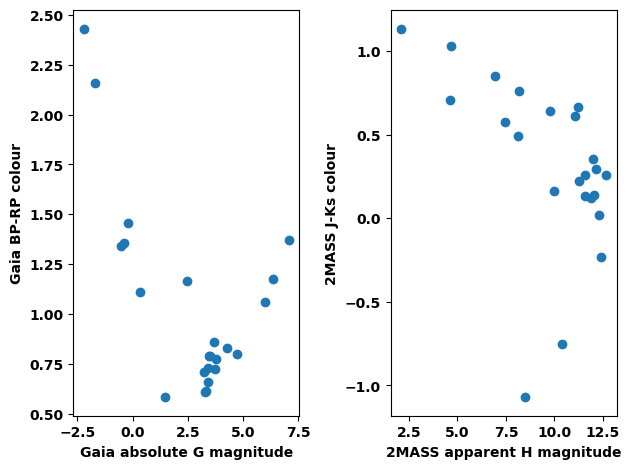

In [31]:
fig, axs = plt.subplots(1,2)
axs[0].scatter(data_cut['Mag_g'],data_cut['bp_rp'])
axs[0].set_xlabel('Gaia absolute G magnitude')
axs[0].set_ylabel('Gaia BP-RP colour')
axs[1].scatter(data_cut['h_m'], data_cut['J-Ks'])
axs[1].set_xlabel('2MASS apparent H magnitude')
axs[1].set_ylabel('2MASS J-Ks colour')
fig.tight_layout()
fig.savefig('figures/color_mag.png')

![pair of colour magnitude diagrams](figures/color_mag.png)

I would not recomend this field for a 2dF/Hermes observation, as while there are 1005 stars in the field, only 23 of them have well defined paralaxes and good photometry. this means that only about $6\%$ of the fibers would be used.